# Multimode Fabry-Perot cavity coupled to SHO drivers

This tutorial uses the `MultiModeSimulation` solver with many non-socket SHO drivers. The setup follows the simple 1D Fabry-Perot cavity #1 parameters from arXiv:2403.12282: 36 photon modes, 36 molecular grid points, `omega_perp = 2320 cm^-1`, and `delta_omega_x = 50 cm^-1`.


## 1. Imports and unit conversions

The multimode solver uses atomic units. The `unit()` helper keeps the input parameters readable.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import maxwelllink as mxl
from maxwelllink.units import unit

cm_to_au = unit("CM_INV", "AU")
au_to_cm = unit("AU", "CM_INV")
au_to_fs = unit("AU", "FS")

## 2. Cavity and SHO parameters

The 36 molecular grid points are placed uniformly along the 1D cavity mirror plane. Each grid point carries one SHO driver in this toy example.

In [ ]:
n_grid = 36
n_mode_x = 36

omega_perp_cm = 2320.0
delta_omega_x_cm = 50.0 
sho_frequency_cm = omega_perp_cm

omega_perp_au = omega_perp_cm * cm_to_au
delta_omega_x_au = delta_omega_x_cm * cm_to_au
sho_frequency_au = sho_frequency_cm * cm_to_au

coupling_strength = 5.0e-5
mu0 = 0.04

dt_fs = 0.5
dt_au = dt_fs * unit("FS", "AU")
total_steps = 3000

print(f"omega_perp = {omega_perp_au:.6e} a.u.")
print(f"delta_omega_x = {delta_omega_x_au:.6e} a.u.")
print(f"dt = {dt_au:.4f} a.u. = {dt_au * au_to_fs:.4f} fs")
print(f"trajectory length = {total_steps * dt_au * au_to_fs:.1f} fs")

omega_perp = 1.057070e-02 a.u.
delta_omega_x = 2.278168e-04 a.u.
dt = 20.6707 a.u. = 0.5000 fs
trajectory length = 1500.0 fs


## 3. Define the SHO drivers

The SHO dipoles are oriented along `y`, because the 1D cavity mode functions couple to the `y` polarization for `y = 0`.

In [3]:
molecules = []
for _ in range(n_grid):
    molecules.append(
        mxl.Molecule(
            driver="sho",
            driver_kwargs={
                "omega": sho_frequency_au,
                "mu0": mu0,
                "orientation": 1,
                "q_initial": 0.0,
                "p_initial": 0.0,
            },
            store_additional_data=False,
        )
    )

[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket mode, using driver: sho
[Init Molecule] Operating in non-socket 

## 4. Run the multimode cavity simulation

In [ ]:
cavity = mxl.FabryPerotCavity(
    frequency_au=omega_perp_au,
    coupling_strength=coupling_strength,
    coupling_axis="y",
    x_grid_1d=np.arange(1, n_grid + 1) / (n_grid + 1),
    y_grid_1d=[0.0],
    delta_omega_x_au=delta_omega_x_au,
    delta_omega_y_au=0.0,
    n_mode_x=n_mode_x,
    n_mode_y=1,
)

qc_initial = np.zeros((n_mode_x, 3))
pc_initial = np.zeros((n_mode_x, 3))
# Initialize the momentum of the cavity modes
pc_initial[:, 1] = np.random.randn(n_grid) * 1e-4

sim = mxl.MultiModeSimulation(
    dt_au=dt_au,
    damping_au=0.0,
    molecules=molecules,
    cavity_geometry=cavity,
    include_dse=True,
    qc_initial=qc_initial,
    pc_initial=pc_initial,
)

sim.run(
    steps=total_steps,
    record_history=True,
    record_to_disk=False,
    record_every_steps=1,
    record_list=["time", "qc", "pc", "energy", "molecule_dipole"],
)

omega_parallel in cm-1 [  50.  100.  150.  200.  250.  300.  350.  400.  450.  500.  550.  600.
  650.  700.  750.  800.  850.  900.  950. 1000. 1050. 1100. 1150. 1200.
 1250. 1300. 1350. 1400. 1450. 1500. 1550. 1600. 1650. 1700. 1750. 1800.]
omega_k in cm-1 [2320.53873055 2322.15417232 2324.84408079 2328.60473245 2333.43095034
 2339.31613939 2346.25233085 2354.23023513 2363.23930231 2373.26778936
 2384.30283311 2396.33052812 2409.33600812 2423.30353031 2438.21656134
 2454.05786403 2470.80958392 2488.45333491 2506.97028303 2526.34122794
 2546.54668129 2567.56694168 2589.38216569 2611.97243477 2635.31781765
 2659.39842822 2684.1944788  2709.68632871 2735.8545283  2762.6798584
 2790.14336549 2818.22639261 2846.91060625 2876.17801953 2906.01101168
 2936.39234436]
Applying Absorbing Boundary Condition : False, cutoff: 0.0
[MultiModeCavity] Recording history: True, to disk: False, record_every_steps: 1, record_max_steps: 3000
[MultiModeCavity] Recording fields : none
[MultiModeCavity] Recor

## 5. Retrieve observables

In [5]:
time_au = np.asarray(sim.time_history)
time_fs = time_au * au_to_fs
qc_y = np.asarray(sim.qc_history)[:, :, 1]
pc_y = np.asarray(sim.pc_history)[:, :, 1]
energy = np.asarray(sim.energy_history)

mode_index = 0
lowest_mode_energy = 0.5 * (
    pc_y[:, mode_index]**2 + sim.omega_k[mode_index]**2 * qc_y[:, mode_index]**2
)

print(qc_y.shape)
print(f"max |Delta E| = {np.max(np.abs(energy - energy[0])):.3e} a.u.")

(3000, 36)
max |Delta E| = 2.356e-09 a.u.


## 6. Dynamics and energy conservation

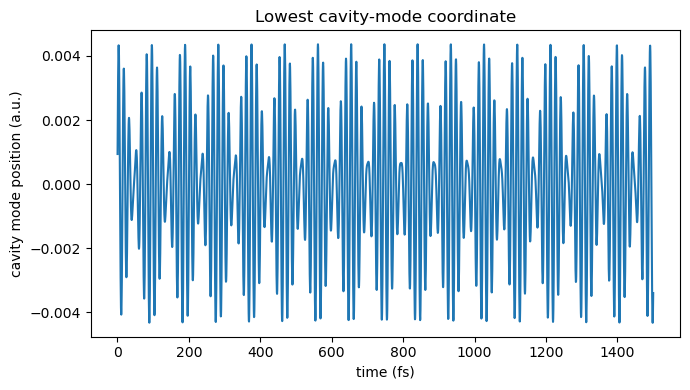

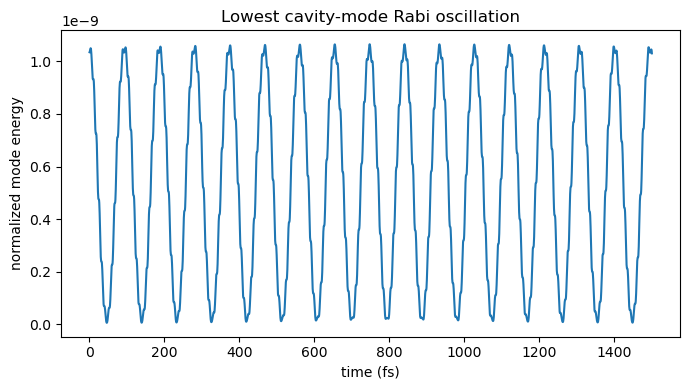

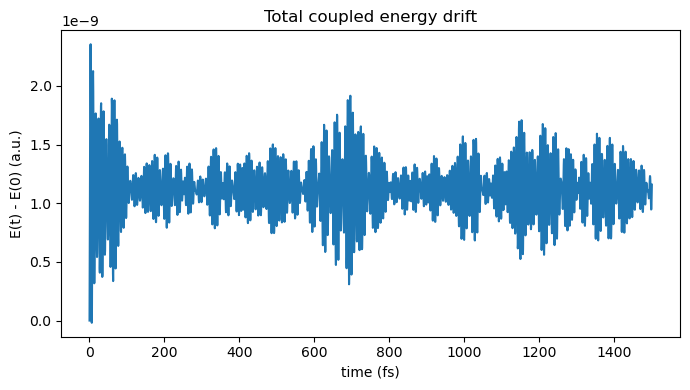

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(time_fs, qc_y[:, mode_index])
plt.xlabel("time (fs)")
plt.ylabel("cavity mode position (a.u.)")
plt.title("Lowest cavity-mode coordinate")
plt.tight_layout()

plt.figure(figsize=(7, 4))
plt.plot(time_fs, lowest_mode_energy)
plt.xlabel("time (fs)")
plt.ylabel("normalized mode energy")
plt.title("Lowest cavity-mode Rabi oscillation")
plt.tight_layout()

plt.figure(figsize=(7, 4))
plt.plot(time_fs, energy - energy[0])
plt.xlabel("time (fs)")
plt.ylabel("E(t) - E(0) (a.u.)")
plt.title("Total coupled energy drift")
plt.tight_layout()

## 7. Polariton dispersion relation

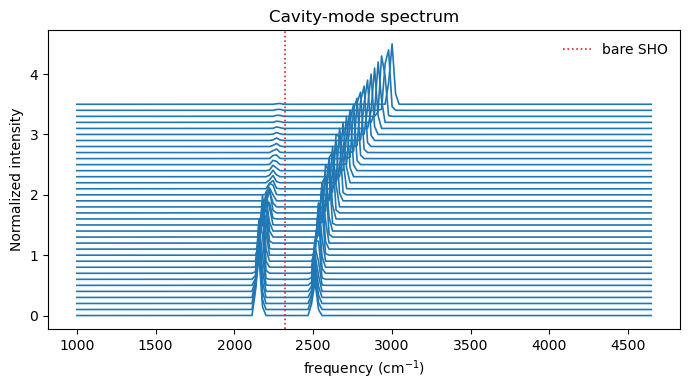

In [7]:
def get_spectrum(idx=0):
    window = np.hanning(qc_y.shape[0])
    signal = (qc_y[:, idx] - qc_y[:, idx].mean()) * window

    freq_au = 2.0 * np.pi * np.fft.rfftfreq(signal.shape[0], d=dt_au)
    freq_cm = freq_au * au_to_cm
    spectrum = np.abs(np.fft.rfft(signal)) ** 2
    spectrum /= max(spectrum.max(), 1.0e-300)

    keep = (freq_cm > 1000.0) & (freq_cm < 4650.0)
    return freq_cm[keep], spectrum[keep]

plt.figure(figsize=(7, 4))

for idx in range(n_grid):
    freq_cm, spectrum = get_spectrum(idx=idx)
    plt.plot(freq_cm, spectrum + 0.1*idx, color="tab:blue", lw=1.2)

plt.axvline(sho_frequency_cm, color="tab:red", ls=":", lw=1.2, label="bare SHO")
plt.xlabel(r"frequency (cm$^{-1}$)")
plt.ylabel("Normalized intensity")
plt.title("Cavity-mode spectrum")
plt.legend(frameon=False)
plt.tight_layout()